# 08 · Multivariate Forecasting with Exogenous Drivers — Predicting a Gold-Miners ETF

Everywhere so far, when we wanted a forecast we mostly fed the model the **target's own past**. In
finance (and macro, and many industrial problems) that's rarely enough: the thing you care about
moves *because other things move*. So we feed the model a **basket of related series** —
**exogenous variables / covariates** — and let it learn the relationships.

**Our target:** a **gold-miners ETF** (think GDX). We pick it deliberately because its return has
*real, explainable structure*:

> Gold miners ≈ **leveraged bet on gold**, **plus** stock-market beta, **minus** the US dollar,
> **minus** real interest rates. When gold rises, the dollar falls, or yields drop, miners tend to
> rally — often by *more* than gold itself.

**Our predictors (the basket):** gold, S&P 500, WTI crude oil, the US Dollar index (DXY),
10-year & 30-year Treasury yields, the VIX (fear index), and **inflation** (monthly, released with
a lag).

We'll build the forecast **two ways** — the two paradigms from this whole series:
- a **multivariate LSTM** (notebooks 02–06): feed sequences where each time step is a *vector* of
  all assets' returns,
- a **LightGBM on engineered lagged features** (notebook 07): the tabular, exogenous-covariate
  approach.

**But finance is where naïve ML goes to die**, so we bake in the four hard lessons up front:
1. **Model returns, not prices** (prices are non-stationary → spurious patterns).
2. **Alignment / no look-ahead** — every predictor must be lagged to *when it was actually known*
   (inflation is monthly and published late!).
3. **Low signal-to-noise** — daily direction is *near* a coin flip; beating baselines is genuinely
   hard, and we'll measure honestly (directional accuracy, and a **backtest with transaction
   costs**).
4. **Explaining ≠ predicting** — same-day drivers explain a *lot* of today's move, but you can't
   trade on data you don't have yet.

> ⚠️ **All data here is synthetic** — realistically *correlated* but invented, so the notebook runs
> offline and reproducibly. Do not treat any result as investment advice; the point is the
> **method and the discipline**, which transfer directly to real data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(11)
torch.manual_seed(11)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| lightgbm", lgb.__version__)

device: cpu | lightgbm 4.6.0


## 1. Simulate a realistic, correlated market

We generate ~9 years of daily data from a few **latent factors**, then build each asset's returns
as a mix of them so the *cross-correlations* look market-like:

- `M` = broad market/risk factor · `Ggold` = gold-specific factor · `D` = US-dollar factor ·
  `R` = real-rates factor · `O` = oil-specific factor.

Then — the crucial bit for a forecasting demo — we add a **small, genuinely predictable
component** to the miners' return that depends on *yesterday's* gold momentum and rate changes.
This mimics the *weak* predictability real markets sometimes show: enough for a model to find a
thin edge, small enough that it's hard and fragile (exactly the honest situation).

In [2]:
N = 2300                      # ~9 years of trading days
def f(): return rng.normal(size=N)      # a standard-normal factor series
M, Ggold, D, R, O = f(), f(), f(), f(), f()
def e(sd): return rng.normal(0, sd, N)

# --- daily returns / changes of each driver (decimal returns; yields in %-points) ---
gold   = 0.010 * (0.85 * Ggold - 0.35 * D - 0.35 * R) + e(0.004)
sp500  = 0.011 * M + e(0.004)
wti    = 0.020 * (0.30 * M + 0.90 * O) + e(0.006)
dxy    = 0.004 * D + e(0.0015)
d10y   = 0.05  * (R + 0.25 * M) + e(0.02)      # daily change in the 10y yield (%pts)
d30y   = 0.045 * (0.90 * R) + e(0.02)
vix    = -0.06 * M + e(0.03)                   # VIX % change: inverse to the market

# --- a small PREDICTABLE signal known one day in advance ---
gold_mom5 = pd.Series(gold).rolling(5).mean().shift(1).fillna(0).values   # yesterday's gold trend
rate_chg5 = pd.Series(d10y).rolling(5).mean().shift(1).fillna(0).values   # yesterday's rate trend
sig = 0.30 * gold_mom5 - 0.20 * rate_chg5
sig = (sig - sig.mean()) / (sig.std() + 1e-9)
predictable = 0.0030 * sig                     # sd ~0.3% of return -> a THIN but real edge

# --- the target: gold-miners ETF return = leveraged gold + market - dollar - rates + edge + noise
miners = (0.020 * (0.90 * Ggold + 0.35 * M - 0.35 * D - 0.45 * R)
          + predictable
          + e(0.010))

# --- inflation: a slow MONTHLY series, published with a 1-month lag (available late!) ---
n_months = N // 21 + 2
cpi_monthly = 2.5 + np.cumsum(rng.normal(0, 0.15, n_months))       # CPI YoY %, random walk
cpi_monthly = np.clip(cpi_monthly, 0.5, 6.0)
cpi_daily_known = np.repeat(cpi_monthly, 21)[:N]                   # step function...
cpi_daily_known = np.roll(cpi_daily_known, 21)                     # ...shifted 1 month = release lag
cpi_daily_known[:21] = cpi_daily_known[21]

dates = pd.bdate_range("2015-01-01", periods=N)
ret = pd.DataFrame({
    "miners": miners, "gold": gold, "sp500": sp500, "wti": wti,
    "dxy": dxy, "d10y": d10y, "d30y": d30y, "vix": vix,
    "inflation": cpi_daily_known,
}, index=dates)
print("shape:", ret.shape, "| span:", ret.index[0].date(), "->", ret.index[-1].date())
ret.head()

shape: (2300, 9) | span: 2015-01-01 -> 2023-10-25


,miners,gold,sp500,wti,dxy,d10y,d30y,vix,inflation
2015-01-01,0.007262,0.006485,-0.004455,0.010886,-0.004434,-0.063247,-0.046709,0.036368,2.224355
2015-01-02,0.042517,0.014501,0.019264,0.000333,0.004308,0.036836,0.023619,-0.108702,2.224355
2015-01-05,0.044476,0.014130,0.008310,-0.030097,-0.005383,0.134745,0.106725,-0.062070,2.224355
2015-01-06,0.019249,-0.002489,0.000861,-0.015260,0.010972,-0.163865,-0.128262,0.027576,2.224355
2015-01-07,0.008094,0.001310,-0.003001,0.002208,0.005215,0.020796,-0.001100,0.010903,2.224355


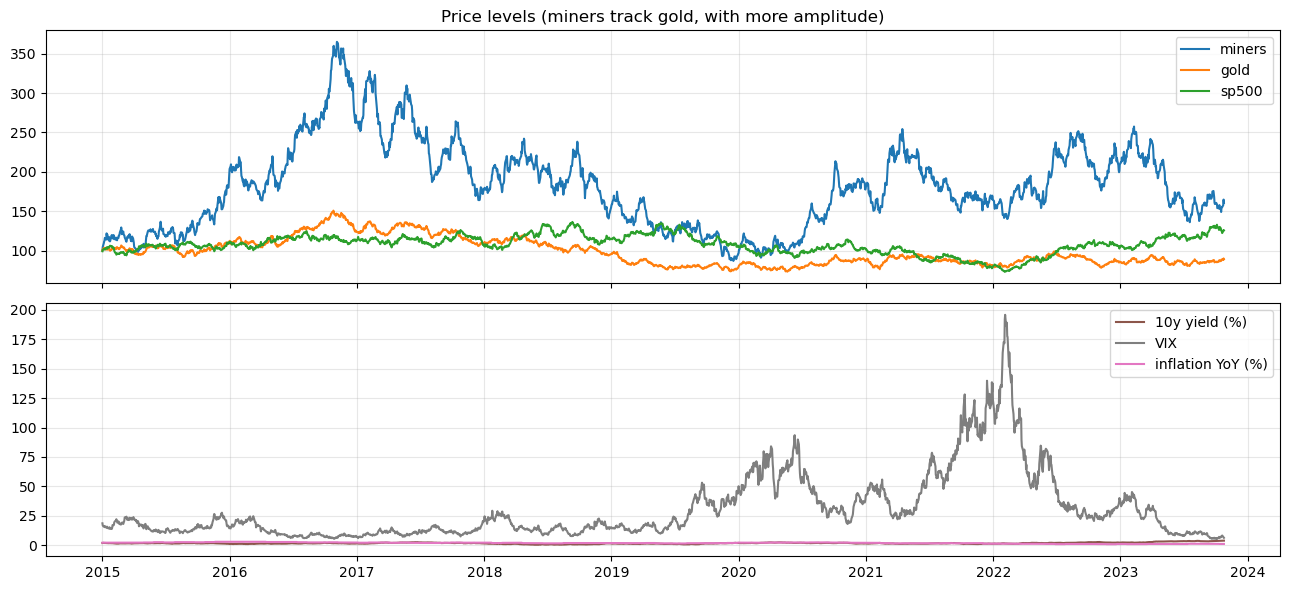

In [3]:
# turn returns/changes into price levels just for a familiar-looking plot
lvl = pd.DataFrame(index=ret.index)
for c in ["miners", "gold", "sp500", "wti"]:
    lvl[c] = 100 * np.exp(ret[c].cumsum())            # price index from returns
lvl["dxy"] = 95 + ret["dxy"].cumsum() * 100
lvl["10y_yield"] = 2.0 + ret["d10y"].cumsum()         # yield level from daily changes
lvl["vix"] = 18 * np.exp(ret["vix"].cumsum())

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for c in ["miners", "gold", "sp500"]:
    ax[0].plot(lvl.index, lvl[c], label=c)
ax[0].set_title("Price levels (miners track gold, with more amplitude)"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(lvl.index, lvl["10y_yield"], color="#8c564b", label="10y yield (%)")
ax[1].plot(lvl.index, lvl["vix"], color="#7f7f7f", label="VIX")
ax[1].plot(lvl.index, ret["inflation"], color="#e377c2", label="inflation YoY (%)")
ax[1].legend(); ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Why returns, not prices? (stationarity)

Feeding **price levels** to a model is a classic trap: prices trend and wander (they're
*non-stationary*), so a model can latch onto the trend and appear brilliant in-sample, then fail
out-of-sample. **Returns** (percent changes) are roughly *stationary* — stable mean/variance over
time — which is what statistical and ML models assume. A quick look makes the difference obvious.

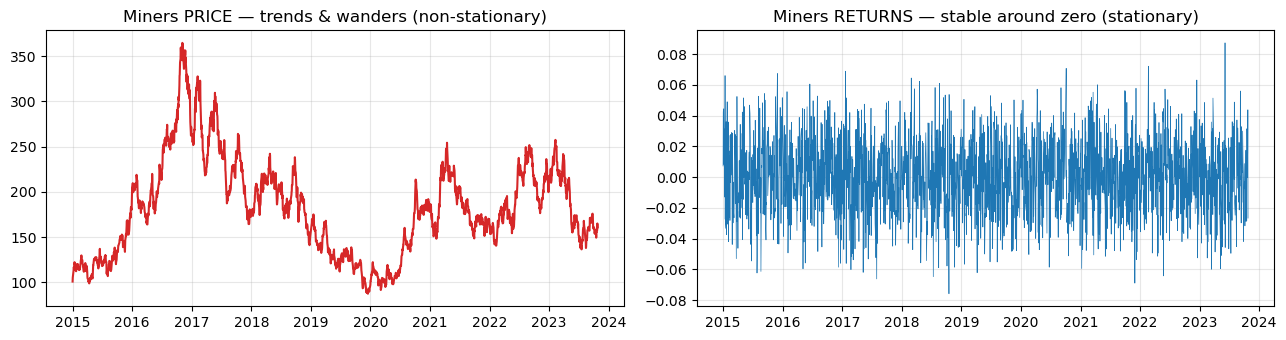

Std of 60-day rolling mean — price: 50.91   returns: 0.00314
The price's local average moves all over; the return's barely does. Model RETURNS.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].plot(lvl.index, lvl["miners"], color="#d62728")
ax[0].set_title("Miners PRICE — trends & wanders (non-stationary)"); ax[0].grid(alpha=0.3)
ax[1].plot(ret.index, ret["miners"], color="#1f77b4", lw=0.5)
ax[1].set_title("Miners RETURNS — stable around zero (stationary)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# rolling mean of the price drifts a lot; rolling mean of returns hugs zero
print("Std of 60-day rolling mean — price: %.2f   returns: %.5f"
      % (lvl['miners'].rolling(60).mean().std(), ret['miners'].rolling(60).mean().std()))
print("The price's local average moves all over; the return's barely does. Model RETURNS.")

## 3. Explaining ≠ predicting (the most important slide)

Here is the distinction that trips up almost everyone new to financial ML.

- **Contemporaneous (same-day) model:** regress *today's* miners return on *today's* gold, S&P,
  dollar, rates… This fits **very well** — because miners genuinely *are* a combination of those.
  But it is **useless for trading**: to use it you'd need to know today's gold move *before* today
  ends. It's an *explanation*, a *nowcast*, not a forecast.
- **Predictive (next-day) model:** predict *tomorrow's* miners return from information available
  **today** (lagged values only). This is the real, hard task — and the fit is **far weaker**.

Let's quantify both with a simple linear regression and compare their R².

In [5]:
drivers = ["gold", "sp500", "wti", "dxy", "d10y", "d30y", "vix"]
split_idx = int(0.7 * len(ret))

# (a) CONTEMPORANEOUS: today's drivers -> today's miners
Xc, yc = ret[drivers].values, ret["miners"].values
lin_c = LinearRegression().fit(Xc[:split_idx], yc[:split_idx])
r2_c = lin_c.score(Xc[split_idx:], yc[split_idx:])

# (b) PREDICTIVE: today's drivers -> TOMORROW's miners (shift target back by 1)
y_next = ret["miners"].shift(-1).values
Xp, yp = Xc[:-1], y_next[:-1]
lin_p = LinearRegression().fit(Xp[:split_idx], yp[:split_idx])
r2_p = lin_p.score(Xp[split_idx:], yp[split_idx:])

print(f"Contemporaneous R² (same-day, NOT tradable): {r2_c:6.3f}   <- explains a LOT")
print(f"Predictive    R² (next-day, the real task) : {r2_p:6.3f}   <- explains very little")
print("\nThat gap is the efficient-market reality: the drivers explain miners, but knowing them")
print("in advance is the hard part. Everything below fights for that tiny predictive R².")

Contemporaneous R² (same-day, NOT tradable):  0.695   <- explains a LOT
Predictive    R² (next-day, the real task) : -0.009   <- explains very little

That gap is the efficient-market reality: the drivers explain miners, but knowing them
in advance is the hard part. Everything below fights for that tiny predictive R².


## 4. Leakage-safe feature engineering across the whole basket

For the **predictive** task we build features **for every series** in the basket, using only
information available *by the close of day t* to predict **day t+1**'s miners return:

- **lagged returns** (t, t−1, t−2) of each asset — today's move is known at the close,
- **momentum** — rolling mean of returns over 5 & 10 days,
- **volatility** — rolling std over 10 days,
- **inflation level** (already lagged to its release date),
- **day-of-week**.

Because today's own return `miners[t]` is known at the close, it's a legitimate feature for
predicting `miners[t+1]` — that's not leakage. Leakage would be using any value dated *after* t.

In [6]:
def build_features(ret_df):
    X = pd.DataFrame(index=ret_df.index)
    assets = ["miners", "gold", "sp500", "wti", "dxy", "d10y", "d30y", "vix"]
    for a in assets:
        s = ret_df[a]
        X[f"{a}_lag0"] = s                       # today's return/change (known at close)
        X[f"{a}_lag1"] = s.shift(1)
        X[f"{a}_lag2"] = s.shift(2)
        X[f"{a}_mom5"] = s.rolling(5).mean()     # short momentum
        X[f"{a}_mom10"] = s.rolling(10).mean()
        X[f"{a}_vol10"] = s.rolling(10).std()    # recent volatility
    X["inflation"] = ret_df["inflation"]         # already release-lagged
    X["dow"] = X.index.dayofweek
    # TARGET: tomorrow's miners return
    y = ret_df["miners"].shift(-1)
    data = X.join(y.rename("target")).dropna()
    return data.drop(columns="target"), data["target"]

Xf, yf = build_features(ret)
print("feature matrix:", Xf.shape, "| features:", Xf.shape[1])

# time-based split (never shuffle!)
n = len(Xf); a, b = int(0.7 * n), int(0.85 * n)
Xtr, ytr = Xf.iloc[:a], yf.iloc[:a]
Xva, yva = Xf.iloc[a:b], yf.iloc[a:b]
Xte, yte = Xf.iloc[b:], yf.iloc[b:]
print(f"train {len(Xtr)} | val {len(Xva)} | test {len(Xte)}")

feature matrix: (2290, 50) | features: 50
train 1603 | val 343 | test 344


## 5. Model 1 — LightGBM on the exogenous feature set

The tabular approach from notebook 07: hand the tree all the lagged multi-asset features and let
it find any predictive structure. We early-stop on the validation block.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12322
[LightGBM] [Info] Number of data points in the train set: 1603, number of used features: 50
[LightGBM] [Info] Start training from score 0.000363
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 40 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

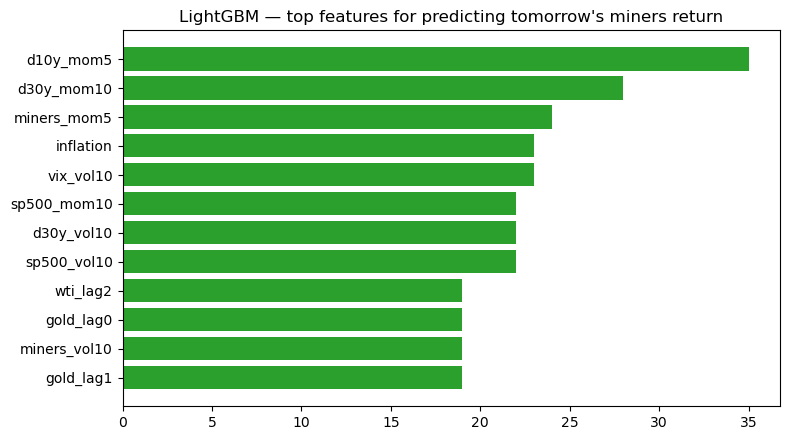

Watch whether gold/rate momentum features surface — that's the injected edge being found.


In [7]:
gbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=31,
                        subsample=0.8, colsample_bytree=0.7, min_child_samples=50,
                        reg_lambda=1.0, random_state=11, n_jobs=-1)
gbm.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="l2",
        callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)])
pred_gbm = gbm.predict(Xte)

# top features the tree leaned on
imp = pd.Series(gbm.feature_importances_, index=Xf.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(8, 4.5))
plt.barh(imp.index[::-1], imp.values[::-1], color="#2ca02c")
plt.title("LightGBM — top features for predicting tomorrow's miners return")
plt.tight_layout(); plt.show()
print("Watch whether gold/rate momentum features surface — that's the injected edge being found.")

## 6. Model 2 — a multivariate LSTM

The sequence approach: each time step is a **vector of all 8 assets' returns**, and the LSTM reads
a 20-day window to predict the next miners return (many-to-one). This is exactly notebook 06's
setup with `features = 8` — the natural way to feed "several related series" to an RNN.

In [8]:
SERIES = ["miners", "gold", "sp500", "wti", "dxy", "d10y", "d30y", "vix"]
WINDOW = 20

# scale each series with TRAIN statistics only (avoid look-ahead)
train_end = int(0.7 * len(ret))
mu = ret[SERIES].iloc[:train_end].mean()
sd = ret[SERIES].iloc[:train_end].std()
scaled = ((ret[SERIES] - mu) / sd).values.astype(np.float32)
target_scaled = ((ret["miners"] - mu["miners"]) / sd["miners"]).values.astype(np.float32)

def make_seq(scaled, target, window):
    Xs, ys, idx = [], [], []
    for i in range(len(scaled) - window - 1):
        Xs.append(scaled[i:i + window])          # (window, n_series)
        ys.append(target[i + window + 1])        # next-day miners (scaled)
        idx.append(i + window)                   # origin date index
    return np.array(Xs), np.array(ys, np.float32), np.array(idx)

Xseq, yseq, idx = make_seq(scaled, target_scaled, WINDOW)
a2, b2 = int(0.7 * len(Xseq)), int(0.85 * len(Xseq))
to_t = lambda z: torch.tensor(z)
Xtr2, ytr2 = to_t(Xseq[:a2]), to_t(yseq[:a2])
Xva2, yva2 = to_t(Xseq[a2:b2]), to_t(yseq[a2:b2])
Xte2, yte2 = to_t(Xseq[b2:]), to_t(yseq[b2:])

class MultiLSTM(nn.Module):
    def __init__(self, n_series=8, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_series, hidden, num_layers=1, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(1)

lstm = MultiLSTM().to(device)
opt = torch.optim.Adam(lstm.parameters(), lr=5e-3, weight_decay=1e-4)
lossf = nn.MSELoss()
Xtr2d, ytr2d, Xva2d = Xtr2.to(device), ytr2.to(device), Xva2.to(device)
best, best_state = 1e9, None
for epoch in range(40):
    lstm.train(); opt.zero_grad()
    loss = lossf(lstm(Xtr2d), ytr2d); loss.backward(); opt.step()
    lstm.eval()
    with torch.no_grad():
        vloss = lossf(lstm(Xva2d), yva2.to(device)).item()
    if vloss < best:                              # keep the best-validation weights
        best, best_state = vloss, {k: v.clone() for k, v in lstm.state_dict().items()}
lstm.load_state_dict(best_state)
with torch.no_grad():
    pred_lstm_scaled = lstm(Xte2.to(device)).cpu().numpy()
pred_lstm = pred_lstm_scaled * sd["miners"] + mu["miners"]     # back to return units
print("LSTM trained. best val MSE (scaled):", round(best, 4))

LSTM trained. best val MSE (scaled): 1.0145


## 7. Honest evaluation — RMSE, directional accuracy, and baselines

Two metrics, and we always compare to the baselines that matter in finance:

- **RMSE of the predicted return** vs the **predict-zero (random-walk)** baseline — the return's own
  standard deviation. If you can't beat "predict 0", you have nothing.
- **Directional accuracy** — how often the *sign* is right vs a 50% coin flip, and vs the majority
  class. This is what a long/short strategy actually cares about.

In [9]:
# align the two models' test targets (LSTM test set is offset by WINDOW+1 vs the tabular one)
# evaluate each on ITS OWN test targets to stay correct.
def report(name, pred, y_true):
    y_true = np.asarray(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    dir_acc = np.mean(np.sign(pred) == np.sign(y_true))
    return name, rmse, dir_acc

zero_rmse = np.sqrt(mean_squared_error(yte, np.zeros_like(yte)))          # predict-zero baseline
maj = np.sign(ytr.mean()) or 1.0
maj_acc_gbm = np.mean(np.sign(np.full_like(yte.values, maj)) == np.sign(yte.values))

rows = [
    ("Predict-zero (random walk)", zero_rmse, np.nan),
    ("Always-majority direction", np.nan, maj_acc_gbm),
    report("LightGBM (features)", pred_gbm, yte.values),
    report("LSTM (multivariate)", pred_lstm, yte2.numpy() * sd['miners'] + mu['miners']),
]
print(f"{'model':<28}{'RMSE':>10}{'DirAcc':>10}")
for name, rmse, acc in rows:
    print(f"{name:<28}{('' if np.isnan(rmse) else f'{rmse:.5f}'):>10}"
          f"{('' if np.isnan(acc) else f'{acc:.1%}'):>10}")
print("\nExpect: tiny RMSE improvement over predict-zero, and directional accuracy only slightly")
print("above 50%. That thin, fragile edge IS what realistic financial forecasting looks like.")

model                             RMSE    DirAcc
Predict-zero (random walk)     0.02326          
Always-majority direction                  49.7%
LightGBM (features)            0.02302     54.7%
LSTM (multivariate)            0.02320     50.3%

Expect: tiny RMSE improvement over predict-zero, and directional accuracy only slightly
above 50%. That thin, fragile edge IS what realistic financial forecasting looks like.


## 8. The only test that matters: a backtest with transaction costs

Directional accuracy above 50% is meaningless if trading it loses money after costs. We turn the
**LightGBM** next-day predictions into a simple **long/short** strategy on the test period:

- position = **+1** (long) if predicted return > 0, else **−1** (short),
- daily P&L = position × *actual* next-day return,
- subtract **transaction costs** (5 bps) every time the position flips,
- compare the equity curve to **buy-and-hold** miners, and report the **Sharpe ratio**.

This is where most "great" models quietly die — costs and turnover eat the thin edge.

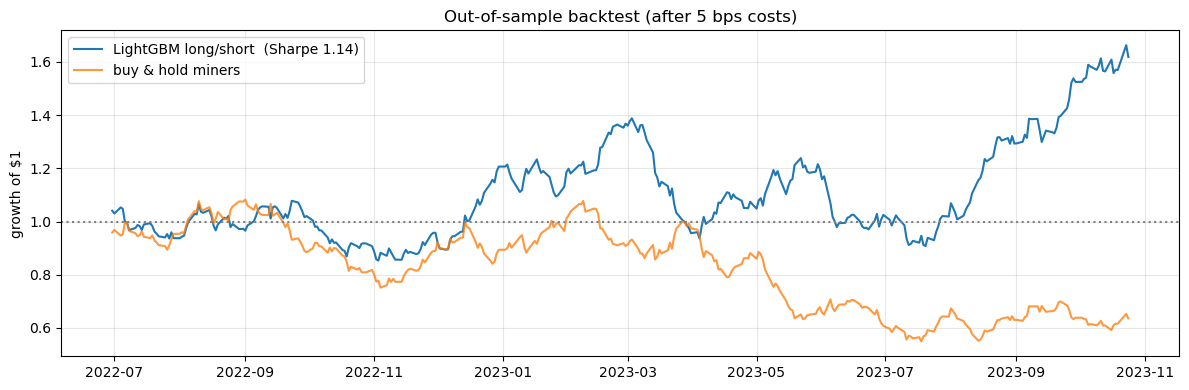

Strategy Sharpe  — with costs: 1.14   |   without costs: 1.39
Final value  — strategy: 1.62   buy&hold: 0.64

Transaction costs trimmed the Sharpe from 1.39 to 1.14 here; with more
turnover or higher costs/slippage they can erase a thin edge entirely.

*** BIG CAVEAT — read this ***
This equity curve looks attractive ONLY because our SYNTHETIC data hides a stable,
non-decaying edge that we injected. Real markets do not hand you that: real edges are
weaker, DECAY as others discover them, and flip across regimes. A pretty backtest on
designed data proves the METHOD runs — never that the strategy would make money live.


In [10]:
def backtest(pred, actual, cost_bps=5):
    actual = np.asarray(actual)
    pos = np.where(pred > 0, 1.0, -1.0)                       # long/short by predicted sign
    turnover = np.abs(np.diff(np.concatenate([[0], pos])))    # 2 when flipping, 0 when holding
    costs = turnover * (cost_bps / 1e4)
    strat = pos * actual - costs
    eq_strat = np.cumprod(1 + strat)
    eq_hold = np.cumprod(1 + actual)
    sharpe = strat.mean() / (strat.std() + 1e-9) * np.sqrt(252)
    return eq_strat, eq_hold, sharpe, strat

eq_s, eq_h, sharpe, strat = backtest(pred_gbm, yte.values, cost_bps=5)
_, _, sharpe_nocost, _ = backtest(pred_gbm, yte.values, cost_bps=0)

plt.figure(figsize=(12, 4))
plt.plot(yte.index, eq_s, label=f"LightGBM long/short  (Sharpe {sharpe:.2f})")
plt.plot(yte.index, eq_h, label="buy & hold miners", alpha=0.8)
plt.axhline(1.0, color="gray", ls=":")
plt.title("Out-of-sample backtest (after 5 bps costs)")
plt.ylabel("growth of $1"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"Strategy Sharpe  — with costs: {sharpe:.2f}   |   without costs: {sharpe_nocost:.2f}")
print(f"Final value  — strategy: {eq_s[-1]:.2f}   buy&hold: {eq_h[-1]:.2f}")
print(f"\nTransaction costs trimmed the Sharpe from {sharpe_nocost:.2f} to {sharpe:.2f} here; with more")
print("turnover or higher costs/slippage they can erase a thin edge entirely.")
print("\n*** BIG CAVEAT — read this ***")
print("This equity curve looks attractive ONLY because our SYNTHETIC data hides a stable,")
print("non-decaying edge that we injected. Real markets do not hand you that: real edges are")
print("weaker, DECAY as others discover them, and flip across regimes. A pretty backtest on")
print("designed data proves the METHOD runs — never that the strategy would make money live.")

## 9. Finance pitfalls & good practice (keep this checklist)

- **Stationarity** — model **returns / changes**, not raw prices or yields levels.
- **No look-ahead / alignment** — lag every predictor to its **real availability** (inflation and
  most macro data are published *days to weeks late*). A single mis-aligned column can manufacture
  a fake edge.
- **Walk-forward / purged CV** — evaluate by rolling forward through time; for overlapping windows
  use **purged & embargoed** cross-validation (López de Prado) to avoid train/test bleed.
- **Costs & turnover** — always backtest net of realistic transaction costs and slippage.
- **Multiple-testing / overfitting** — try enough features/models and one will look great by luck.
  Prefer simple models, out-of-sample discipline, and a healthy prior of *"probably no edge."*
- **Backtest optimism** — a beautiful equity curve (like §8's) most often means a **bug, leakage,
  or in-sample-designed signal**, not a money machine. Our synthetic data has a *stable* injected
  edge; real edges are weaker and **decay**. Always suspect a pretty backtest first.
- **Regime change** — relationships (miners↔rates, stocks↔oil) shift; retrain and monitor.
- **Signal vs noise** — daily direction is ~a coin flip; edges live in **risk management, position
  sizing, and cost control** as much as in prediction.

## 10. Does multivariate help? RNN vs GBDT here

- **Yes, the basket matters** — contemporaneously the drivers explain most of miners' variance
  (§3), and predictively the small edge lived in *cross-asset* momentum (gold/rate features), which
  a miners-only model couldn't see. Exogenous inputs are the whole game in macro-driven assets.
- **GBDT vs LSTM for this:** on tabular, low-signal, modest-data financial problems, **LightGBM on
  well-engineered lagged features is usually the stronger, more robust default** — it's fast, hard
  to overfit with regularization, and interpretable. The **LSTM** earns its keep when you have
  **long, high-frequency** sequences (intraday/tick data) with complex temporal shape and lots of
  data. Many desks use **both** and ensemble them.
- **State of the art** for multi-series forecasting with covariates now also includes
  **Temporal Fusion Transformers**, **N-HiTS**, and **DeepAR** — but they demand more data and
  care, and rarely beat a disciplined GBDT on thin-signal daily finance.

## 11. Recap

You now know how to **feed a basket of exogenous series** to forecast a target — the technique
behind "predict the ETF using gold, S&P 500, WTI, yields, inflation…" — in **both** paradigms:

- **LSTM:** stack the assets as `features` in the `(batch, time, features)` tensor.
- **GBDT:** engineer **lagged** features for every asset and feed the table to LightGBM.

And, just as important, you know the **finance-specific discipline** — returns not prices,
strict alignment, walk-forward validation, and backtesting net of costs — that separates a real
signal from a beautiful illusion.

> This closes the series: **01–06** taught RNNs end-to-end, **07** taught features→GBDT, and **08**
> combined them on the hardest, most-requested case — multivariate financial forecasting with
> exogenous drivers.